# Toronto Bikeshare Mobility Patterns (2018) — Python

## Context

Bikeshare systems are a growing component of sustainable urban mobility. Understanding usage patterns, when people ride, which stations are most connected, how trip durations vary, helps city planners optimize station placement, anticipate maintenance needs, and design infrastructure that encourages cycling over car travel.

This project analyzes **1.9 million bikeshare trips** from Toronto's 2018 ridership data using **pandas** and **NetworkX**, covering temporal patterns, station-level analytics, and network analysis.


## Data

Download the four quarterly CSV files from [Kaggle](https://www.kaggle.com/jackywang529/toronto-bikeshare-data) and place them in the same directory as this notebook (or adjust `data_path` below).

## 1. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx

import warnings
warnings.filterwarnings('ignore')

print('Setup complete.')

Setup complete.


## 2. Data Loading & Integration

The dataset consists of four quarterly CSV files from Toronto's bikeshare system (2018), totaling ~1.9 million individual trips. Each row represents one trip with origin station, destination station, timestamps, duration, and user type.

In [2]:
# Adjust path to your environment
data_path = '/content/'

quarters = ['Q1', 'Q2', 'Q3', 'Q4']
dfs = []
for q in quarters:
    df = pd.read_csv(f'{data_path}Bike Share Toronto Ridership_{q} 2018.csv')
    dfs.append(df)
    print(f'{q}: {len(df):>10,} trips')

trips = pd.concat(dfs, ignore_index=True)
print(f'{"":-<30}')
print(f'Total: {len(trips):>9,} trips')
print(f'\nColumns: {list(trips.columns)}')

Q1:    178,559 trips
Q2:    558,370 trips
Q3:    822,536 trips
Q4:    363,490 trips
------------------------------
Total: 1,922,955 trips

Columns: ['trip_id', 'trip_duration_seconds', 'from_station_id', 'trip_start_time', 'from_station_name', 'trip_stop_time', 'to_station_id', 'to_station_name', 'user_type']


In [3]:
trips.head()

,trip_id,trip_duration_seconds,from_station_id,trip_start_time,from_station_name,trip_stop_time,to_station_id,to_station_name,user_type
0,2383648,393,7018,1/1/2018 0:47,Bremner Blvd / Rees St,1/1/2018 0:54,7176,Bathurst St / Fort York Blvd,Annual Member
1,2383649,625,7184,1/1/2018 0:52,Ossington Ave / College St,1/1/2018 1:03,7191,Central Tech (Harbord St),Annual Member
2,2383650,233,7235,1/1/2018 0:55,Bay St / College St (West Side) - SMART,1/1/2018 0:59,7021,Bay St / Albert St,Annual Member
3,2383651,1138,7202,1/1/2018 0:57,Queen St W / York St (City Hall),1/1/2018 1:16,7020,Phoebe St / Spadina Ave,Annual Member
4,2383652,703,7004,1/1/2018 1:00,University Ave / Elm St,1/1/2018 1:12,7060,Princess St / Adelaide St E,Annual Member


### Variables

| Variable | Description |
|---|---|
| `trip_id` | Unique trip identifier |
| `trip_duration_seconds` | Trip duration in seconds |
| `from_station_id` / `from_station_name` | Origin station ID and nearest intersection |
| `to_station_id` / `to_station_name` | Destination station ID and nearest intersection |
| `trip_start_time` / `trip_stop_time` | Trip start and end timestamps |
| `user_type` | Annual Member or Casual User |

## 3. Preprocessing

In [4]:
# Parse timestamps
trips['trip_start_time'] = pd.to_datetime(trips['trip_start_time'], format='mixed')
trips['trip_stop_time']  = pd.to_datetime(trips['trip_stop_time'], format='mixed')

# Drop rows with null start times
trips = trips.dropna(subset=['trip_start_time'])

# Extract temporal features
trips['month'] = trips['trip_start_time'].dt.month
trips['month_name'] = trips['trip_start_time'].dt.strftime('%b')
trips['hour'] = trips['trip_start_time'].dt.hour

# Ensure duration is numeric
trips['trip_duration_seconds'] = pd.to_numeric(trips['trip_duration_seconds'], errors='coerce')

print(f'Trips with valid timestamps: {len(trips):,}')
trips[['trip_id', 'trip_start_time', 'month_name', 'hour', 'trip_duration_seconds']].head()

Trips with valid timestamps: 1,922,955


,trip_id,trip_start_time,month_name,hour,trip_duration_seconds
0,2383648,2018-01-01 00:47:00,Jan,0,393
1,2383649,2018-01-01 00:52:00,Jan,0,625
2,2383650,2018-01-01 00:55:00,Jan,0,233
3,2383651,2018-01-01 00:57:00,Jan,0,1138
4,2383652,2018-01-01 01:00:00,Jan,1,703


## 4. Temporal Analysis

### 4.1. Monthly trip volume

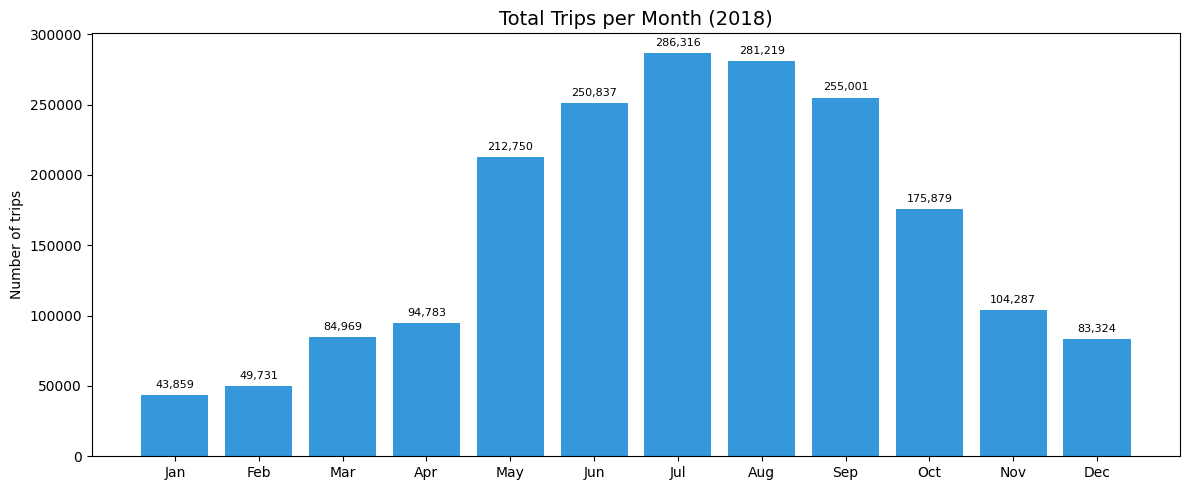

In [5]:
monthly_trips = trips.groupby('month').size()
month_labels = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

fig, ax = plt.subplots(figsize=(12, 5))
ax.bar(month_labels, monthly_trips.values, color='#3498db')
ax.set_title('Total Trips per Month (2018)', fontsize=14)
ax.set_ylabel('Number of trips')

for i, v in enumerate(monthly_trips.values):
    ax.text(i, v + 5000, f'{v:,.0f}', ha='center', fontsize=8)

plt.tight_layout()
plt.show()

### 4.2. Trips by hour and month (heatmap)

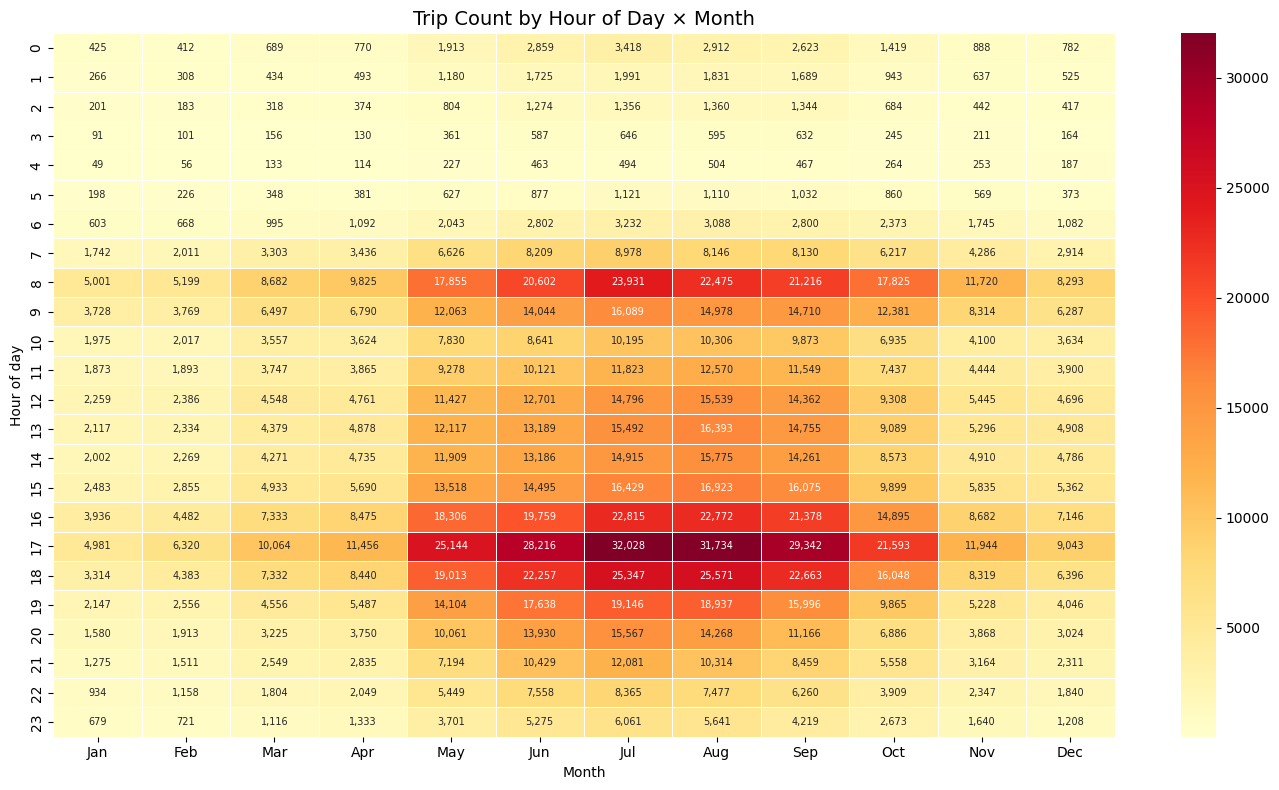

In [6]:
pivot = trips.pivot_table(index='hour', columns='month', values='trip_id', aggfunc='count')
pivot.columns = month_labels

fig, ax = plt.subplots(figsize=(14, 8))
sns.heatmap(pivot, cmap='YlOrRd', fmt=',d', annot=True, ax=ax,
            linewidths=0.5, annot_kws={'size': 7})
ax.set_title('Trip Count by Hour of Day × Month', fontsize=14)
ax.set_ylabel('Hour of day')
ax.set_xlabel('Month')
plt.tight_layout()
plt.show()

Two patterns are immediately visible. First, **commuting peaks** at 8 AM and 5-6 PM are consistent across all months. Second, **seasonal variation** is extreme: summer months (Jun-Aug) have 5-10x more trips than winter (Jan-Feb), reflecting Toronto's climate.

### 4.3. Hourly profile by season

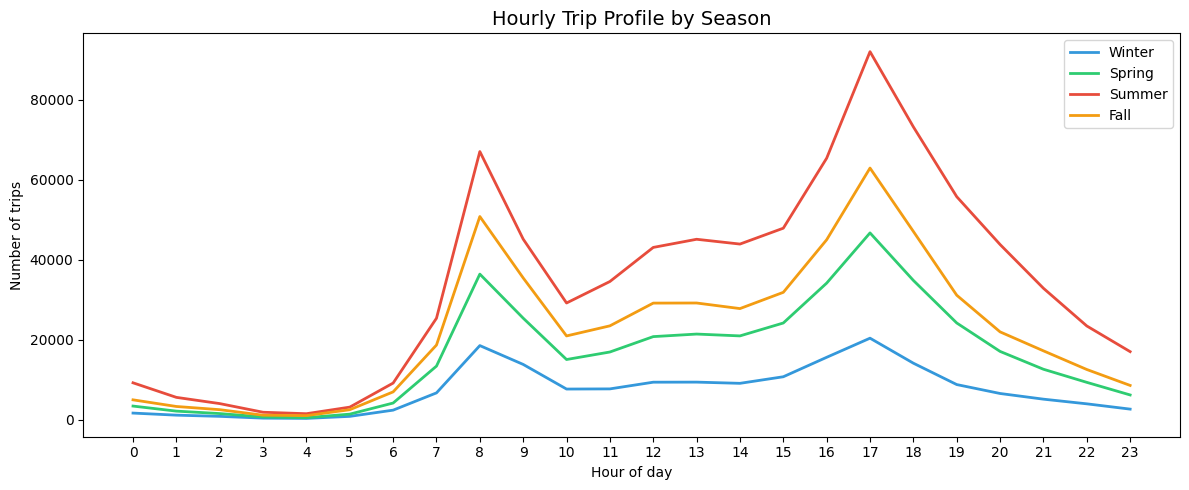

In [7]:
trips['season'] = trips['month'].map({12: 'Winter', 1: 'Winter', 2: 'Winter', 3: 'Spring', 4: 'Spring',
    5: 'Spring', 6: 'Summer', 7: 'Summer', 8: 'Summer', 9: 'Fall', 10: 'Fall', 11: 'Fall'})

hourly_season = trips.groupby(['hour', 'season']).size().reset_index(name='trips')

fig, ax = plt.subplots(figsize=(12, 5))
for season, color in [('Winter', '#3498db'), ('Spring', '#2ecc71'),
                       ('Summer', '#e74c3c'), ('Fall', '#f39c12')]:
    data = hourly_season[hourly_season['season'] == season]
    ax.plot(data['hour'], data['trips'], label=season, color=color, linewidth=2)

ax.set_title('Hourly Trip Profile by Season', fontsize=14)
ax.set_xlabel('Hour of day')
ax.set_ylabel('Number of trips')
ax.legend()
ax.set_xticks(range(0, 24))
plt.tight_layout()
plt.show()

## 5. Station-Level Analytics

For each trip, I compute aggregate statistics (mean, min, max duration) across all trips that departed from the **same station, at the same hour, in the same month**. This is the pandas equivalent of Spark's window functions, using `groupby().transform()`.

In [8]:
group_cols = ['from_station_id', 'hour', 'month']

trips['avg_duration'] = trips.groupby(group_cols)['trip_duration_seconds'].transform('mean')
trips['min_duration'] = trips.groupby(group_cols)['trip_duration_seconds'].transform('min')
trips['max_duration'] = trips.groupby(group_cols)['trip_duration_seconds'].transform('max')
trips['pct_deviation'] = ((trips['trip_duration_seconds'] - trips['avg_duration']) / trips['avg_duration']) * 100

trips[['trip_id', 'from_station_name', 'month_name', 'hour','trip_duration_seconds', 'avg_duration',
       'min_duration', 'max_duration', 'pct_deviation']].head(10)

,trip_id,from_station_name,month_name,hour,trip_duration_seconds,avg_duration,min_duration,max_duration,pct_deviation
0,2383648,Bremner Blvd / Rees St,Jan,0,393,580.000000,393,767,-32.241379
1,2383649,Ossington Ave / College St,Jan,0,625,443.500000,262,625,40.924464
2,2383650,Bay St / College St (West Side) - SMART,Jan,0,233,226.666667,191,256,2.794118
3,2383651,Queen St W / York St (City Hall),Jan,0,1138,1138.000000,1138,1138,0.000000
4,2383652,University Ave / Elm St,Jan,1,703,786.500000,703,870,-10.616656
5,2383653,College St / Major St,Jan,1,1026,643.500000,234,1061,59.440559
6,2383654,Bay St / Albert St,Jan,1,274,417.500000,274,561,-34.371257
7,2383655,Niagara St / Richmond St W,Jan,1,764,764.000000,764,764,0.000000
8,2383657,Church St / Alexander St,Jan,1,237,629.000000,237,894,-62.321145
9,2383658,Queen St W / Cowan Ave,Jan,1,180,180.000000,180,180,0.000000


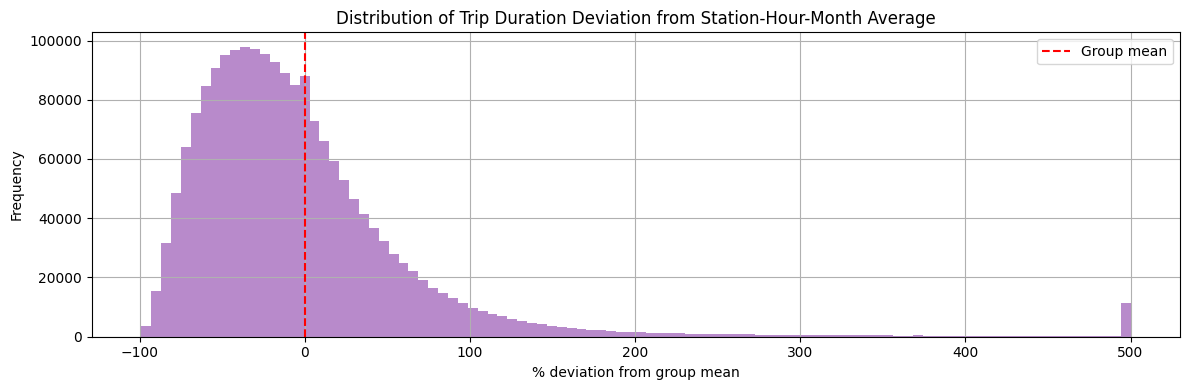

In [9]:
# Distribution of trip deviation from group mean
fig, ax = plt.subplots(figsize=(12, 4))
trips['pct_deviation'].clip(-200, 500).hist(bins=100, ax=ax, color='#9b59b6', alpha=0.7)
ax.axvline(0, color='red', linestyle='--', label='Group mean')
ax.set_title('Distribution of Trip Duration Deviation from Station-Hour-Month Average', fontsize=12)
ax.set_xlabel('% deviation from group mean')
ax.set_ylabel('Frequency')
ax.legend()
plt.tight_layout()
plt.show()

## 6. Network Analysis: Station Graph & PageRank

Bikeshare stations form a directed graph where each unique origin→destination pair is an edge. **PageRank** identifies stations that are not just popular, but **structurally central**: they receive trips from many well-connected stations.

In [10]:
# Build directed graph from unique routes
edges = trips[['from_station_id', 'to_station_id']].drop_duplicates()

G = nx.DiGraph()
G.add_edges_from(edges.values)

print(f'Stations (nodes):  {G.number_of_nodes()}')
print(f'Unique routes (edges): {G.number_of_edges()}')

Stations (nodes):  359
Unique routes (edges): 83197


In [11]:
# Compute PageRank
pagerank = nx.pagerank(G, max_iter=100)

pr_df = (pd.DataFrame({'station_id': pagerank.keys(), 'pagerank': pagerank.values()})
    .sort_values('pagerank', ascending=False)
    .reset_index(drop=True))

# Add station names
station_names = (trips[['from_station_id', 'from_station_name']]
    .drop_duplicates()
    .rename(columns={'from_station_id': 'station_id', 'from_station_name': 'station_name'}))
pr_df = pr_df.merge(station_names, on='station_id', how='left')

print('Top 10 stations by PageRank:\n')
pr_df.head(10)

Top 10 stations by PageRank:



,station_id,pagerank,station_name
0,7060,0.004019,Princess St / Adelaide St E
1,7016,0.003824,Bay St / Queens Quay W (Ferry Terminal)
2,7076,0.003795,York St / Queens Quay W
3,7102,0.003783,Nelson St / Duncan St
4,7022,0.003761,Simcoe St / Queen St W
5,7168,0.003735,Queens Quay / Yonge St
6,7021,0.003718,Bay St / Albert St
7,7043,0.003705,Queens Quay W / Lower Simcoe St
8,7038,0.003697,Dundas St W / Yonge St
9,7019,0.003696,Temperance St. Station


In [12]:
# Trip statistics for the most relevant station
top_station_id = pr_df.iloc[0]['station_id']
top_station_name = pr_df.iloc[0]['station_name']

top_stats = trips[trips['from_station_id'] == top_station_id]['trip_duration_seconds'].agg(
    ['mean', 'min', 'max', 'count'])

print(f'Most relevant station: ID {int(top_station_id)} — {top_station_name}')
print(f'\nTrips departing: {int(top_stats["count"]):,}')
print(f'Avg duration:   {top_stats["mean"]:.1f} sec ({top_stats["mean"]/60:.1f} min)')
print(f'Min duration:   {int(top_stats["min"])} sec')
print(f'Max duration:   {int(top_stats["max"]):,} sec ({top_stats["max"]/3600:.1f} hours)')

Most relevant station: ID 7060 — Princess St / Adelaide St E

Trips departing: 17,089
Avg duration:   747.7 sec (12.5 min)
Min duration:   61 sec
Max duration:   35,130 sec (9.8 hours)


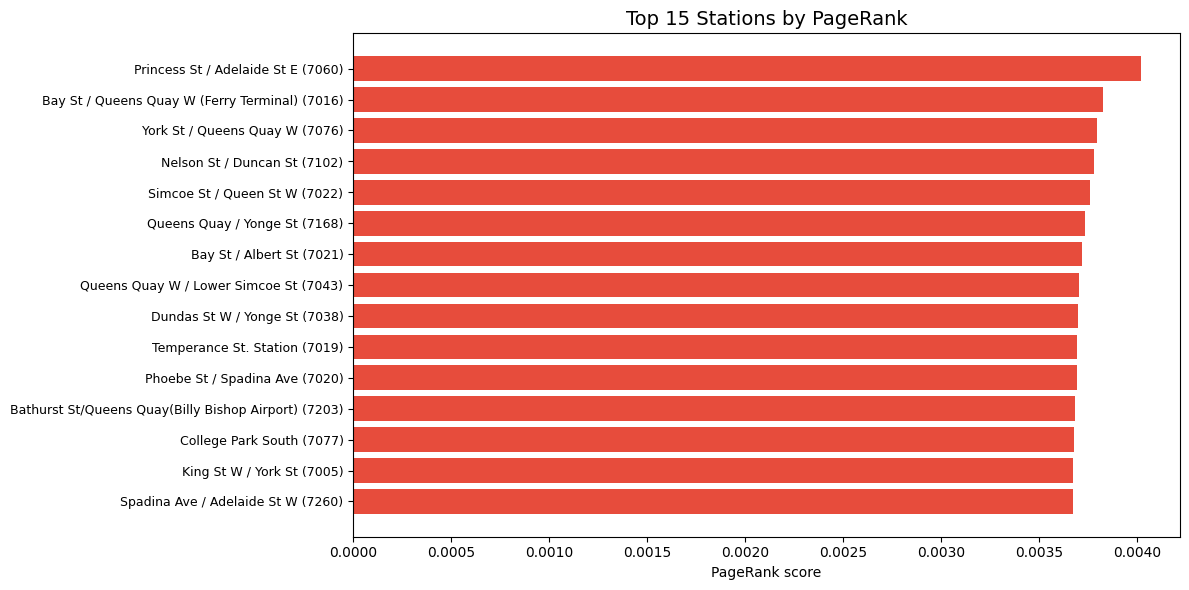

In [13]:
# Visualize top 15 stations by PageRank
fig, ax = plt.subplots(figsize=(12, 6))
top15 = pr_df.head(15)
ax.barh(range(len(top15)), top15['pagerank'], color='#e74c3c')
ax.set_yticks(range(len(top15)))
ax.set_yticklabels([f"{row['station_name']} ({int(row['station_id'])})"
                     for _, row in top15.iterrows()], fontsize=9)
ax.invert_yaxis()
ax.set_title('Top 15 Stations by PageRank', fontsize=14)
ax.set_xlabel('PageRank score')
plt.tight_layout()
plt.show()

## 7. Reflections

### Key findings

- **Commuting dominates**: The 8 AM and 5-6 PM peaks confirm that bikeshare serves a significant commuter function in Toronto.
- **Seasonality is extreme**: Summer-to-winter ratios of 5-10x suggest that interventions like bike lane snow clearing could extend ridership.
- **Hub stations emerge from network structure**: PageRank reveals structurally important stations that may not rank highest by raw trip counts.

### Technical note: pandas vs. PySpark

This analysis was originally developed in PySpark on Azure Databricks (see the [Spark version](https://github.com/4ra-BB/toronto-bikeshare-spark)). For 1.9M rows, pandas handles the workload comfortably on a standard machine. The value of PySpark becomes clear at larger scales (10M+ rows) or when processing must be distributed across a cluster. Both implementations produce identical results.

### Broader relevance

Urban bikeshare data sits at the intersection of sustainable transport, public health, and urban planning. The techniques demonstrated here, as temporal pattern analysis, contextual station profiling, and network centrality, are transferable to other mobility and infrastructure contexts: bus networks, pedestrian flows, sport facility usage, or community resource allocation.